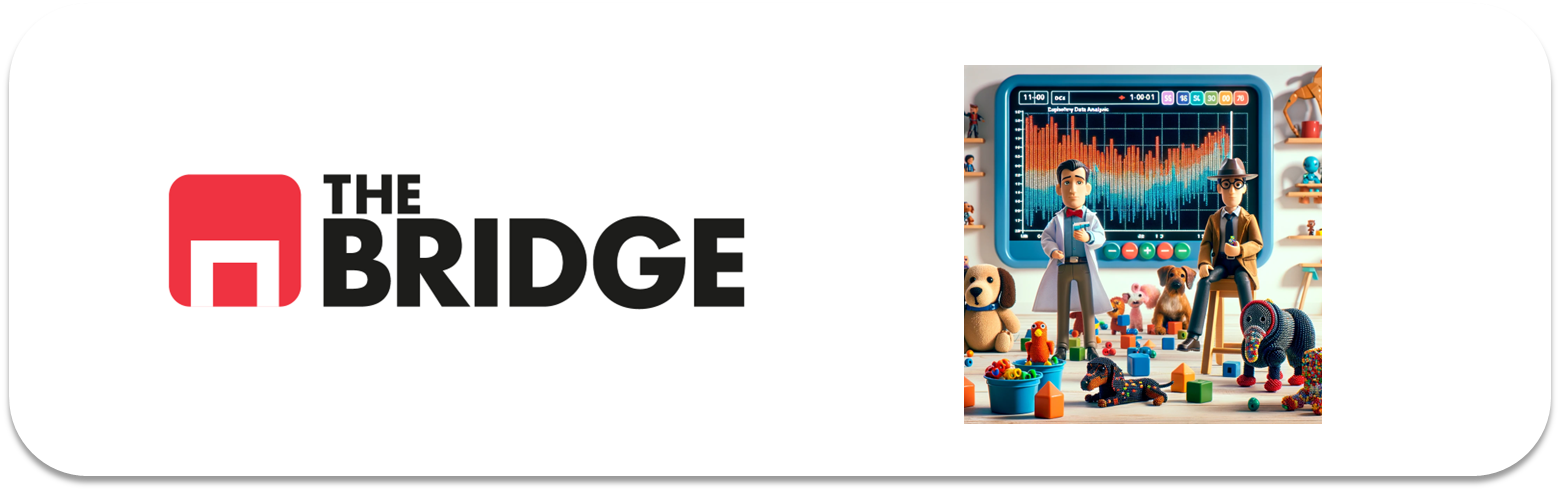

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df_2 = df.copy()

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [4]:
df_2.drop(["deck","survived","pclass","embarked"], axis=1, inplace=True)
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          891 non-null    str    
 1   age          714 non-null    float64
 2   sibsp        891 non-null    int64  
 3   parch        891 non-null    int64  
 4   fare         891 non-null    float64
 5   class        891 non-null    str    
 6   who          891 non-null    str    
 7   adult_male   891 non-null    bool   
 8   embark_town  889 non-null    str    
 9   alive        891 non-null    str    
 10  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(2), str(5)
memory usage: 64.5 KB


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [6]:
df_2["family_members"] = df_2["parch"]+df_2["sibsp"]
df_2.drop(["parch","sibsp"], axis=1, inplace = True)

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [9]:
embark_town_mode = df_2["embark_town"].mode()[0]

In [10]:
df_2.loc[df_2["embark_town"].isna(), "embark_town"] = embark_town_mode

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [11]:
# Imputo el valor por who en age:

# Columna con flags de imputación
df["age_imputed"] = df.age.isna()

# Máscaras por género
is_woman = df.who == "woman"
is_child = df.who == "child"
is_man = df.who == "man"

# Valores medianos
mediana_woman = df.loc[is_woman,"age"].median()
mediana_child = df.loc[is_child,"age"].median() # No hay chiquillos nulos, pero por si acaso...
mediana_man = df.loc[is_man,"age"].median()

# Imputamos
df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man & df["age_imputed"], "age"] = mediana_man

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

Se observa que la variable más relevante es "alive"

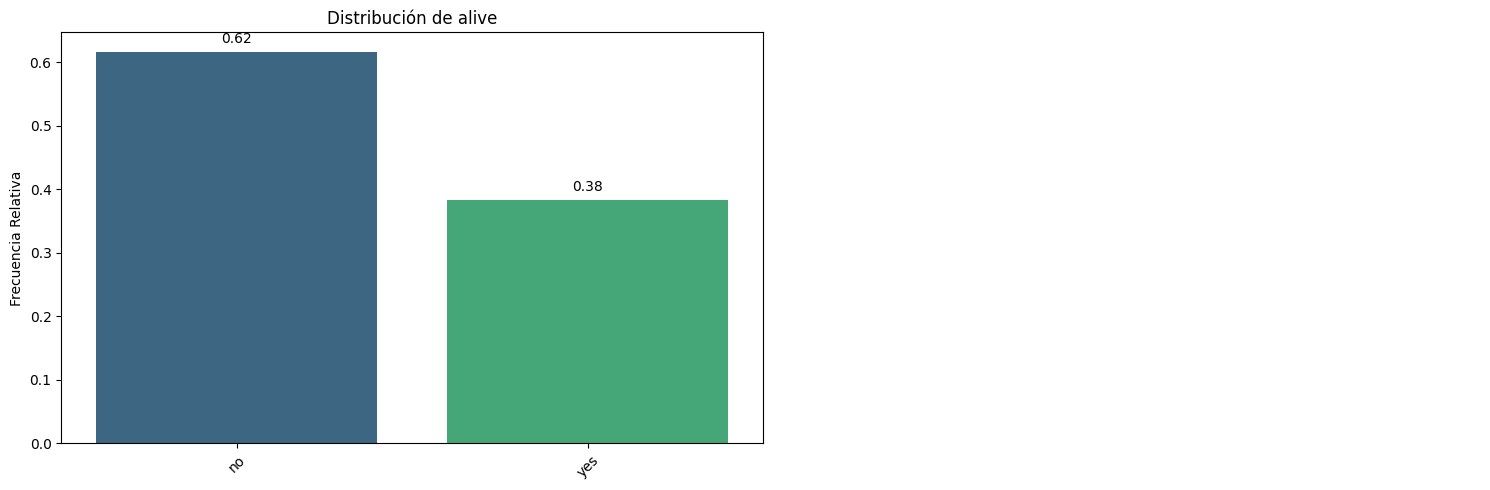

In [13]:
pinta_distribucion_categoricas(df_2, ["alive"], relativa= True, mostrar_valores= True)

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

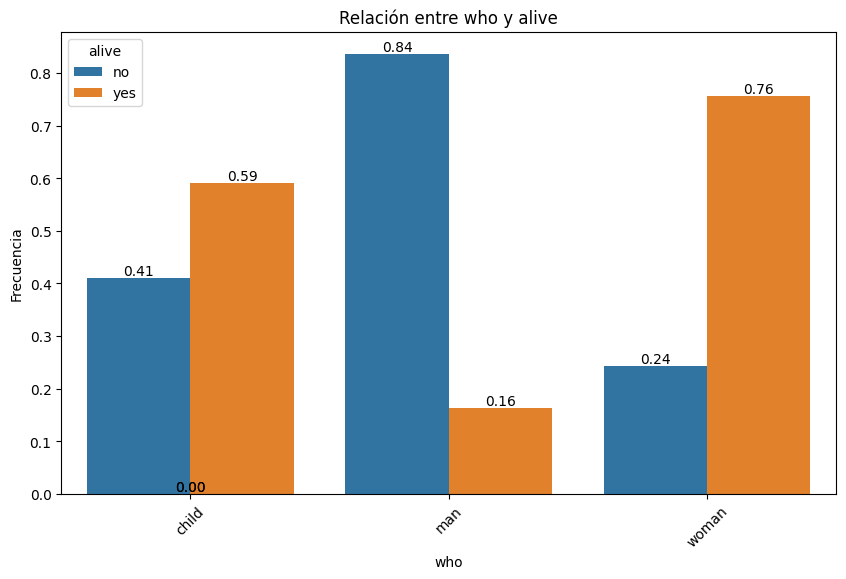

In [16]:
plot_categorical_relationship_fin(df_2,"who","alive", relative_freq= True, show_values= True)

- En términos absolutos, se observa que hubo más muertes de hombres que de mujeres. 
- En términos relativos, las mujeres presentan la frecuencia más alta, seguida de los niños y en último lugar los hombres.

In [17]:
# Para comparar la relación entre grupo de edad y sexo (variable who) y supervivencia, empleamos el test chi2

tabla_contingencia = pd.crosstab(df["alive"], df["who"])

chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p_value)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


- Al ser el valor p muy inferior a 0.05 podemos afirmar que existe dependencia entre la variable edad y sexo con la supervivencia, siendo significativa estadísticamente.
- Llama la atención que la supervivencia de los niños sea más baja que la de las mujeres, sería interesante estudiarlo con un analisis multivariante.

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

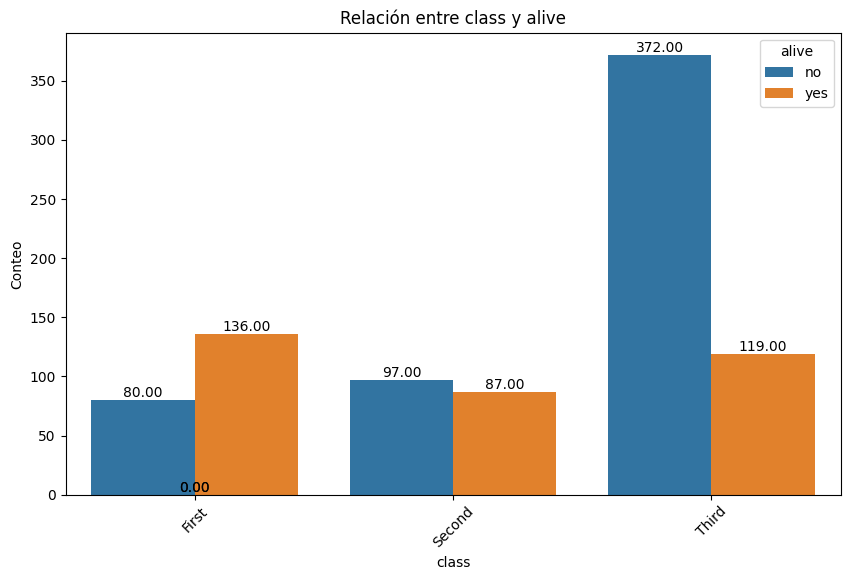

In [18]:
plot_categorical_relationship_fin(df_2, "class","alive", show_values = True)

- En términos absolutos, hubo más muertes de pasajeros de tercera clase. Siendo la primera clase los que más sobrevivientes, seguida de la tercera y luego la segunda.

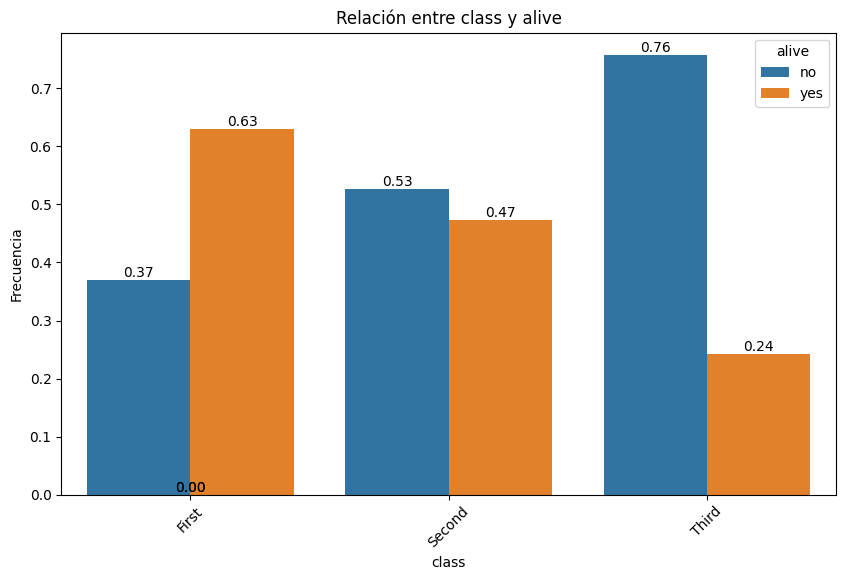

In [19]:
plot_categorical_relationship_fin(df_2, "class","alive", relative_freq=True ,show_values = True)

- En términos relativos, observamos esa diferencia más notable. La primera clase tiene mayor cantidad de superviviente, seguida de la segunda y en último lugar la tercera [63%-47%-24%]

In [21]:
tabla_contingencia = pd.crosstab(df_2["alive"],df_2["class"])

chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p_value)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


El valor - p está muy por debajo de 0.05, por lo tanto se demuestra la existencia de una relación entre clase y la supervivencia

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

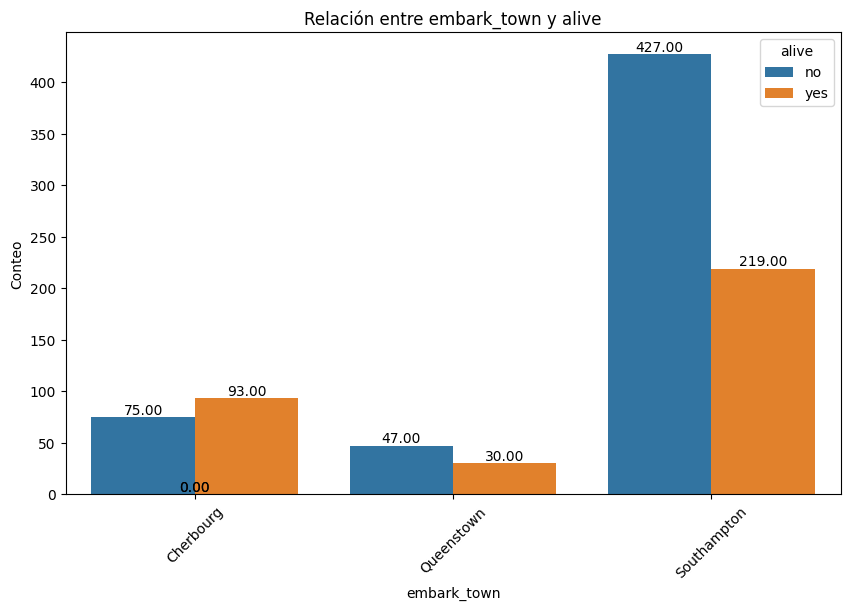

In [23]:
plot_categorical_relationship_fin(df_2, "embark_town","alive", show_values= True)

- En términos absolutos, hubo más supervivientes de la ciudad Southampton. Esto se debe de que hubo más embarcaciones desde esta ciudad

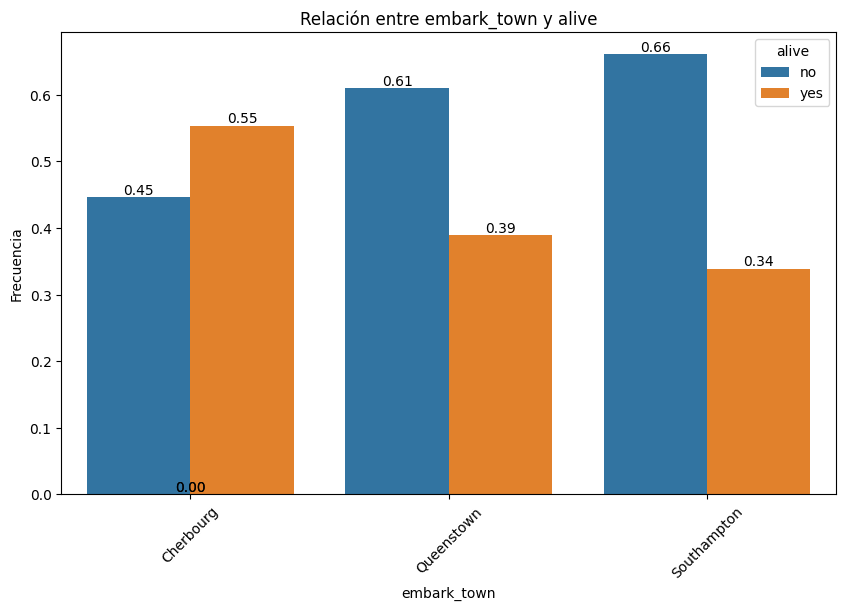

In [28]:
plot_categorical_relationship_fin(df_2, "embark_town","alive", show_values= True, relative_freq= True)

- En términos relativos, observamos que los pasajeros provenientes de Cherbourg han tenido un mayor porcentaje de supervivencia, después de los pasajeros de Queenstown y Southampton [55%-39%-34%]

In [29]:
tabla_contingencia = pd.crosstab(df_2["alive"],df["embark_town"])

chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p_value)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 26.48914983923762
P-Value: 1.769922284120912e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.7480315  47.5511811 397.7007874]
 [ 64.2519685  29.4488189 246.2992126]]


El valor p demuestra que existe una relación estadística entre la ciudad de embarco con la supervivencia de los extranjeros.

Veamos si tiene algo que ver la clase más frecuente según cada puerto, como vimos en el analisis anterior, tiene relación con la supervivencia

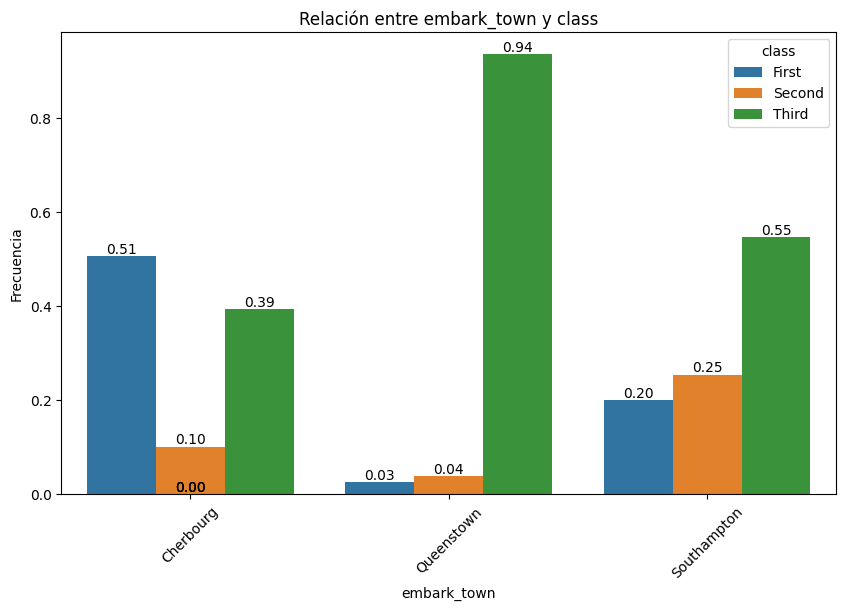

In [30]:
plot_categorical_relationship_fin(df_2, "embark_town","class", relative_freq= True, show_values= True)

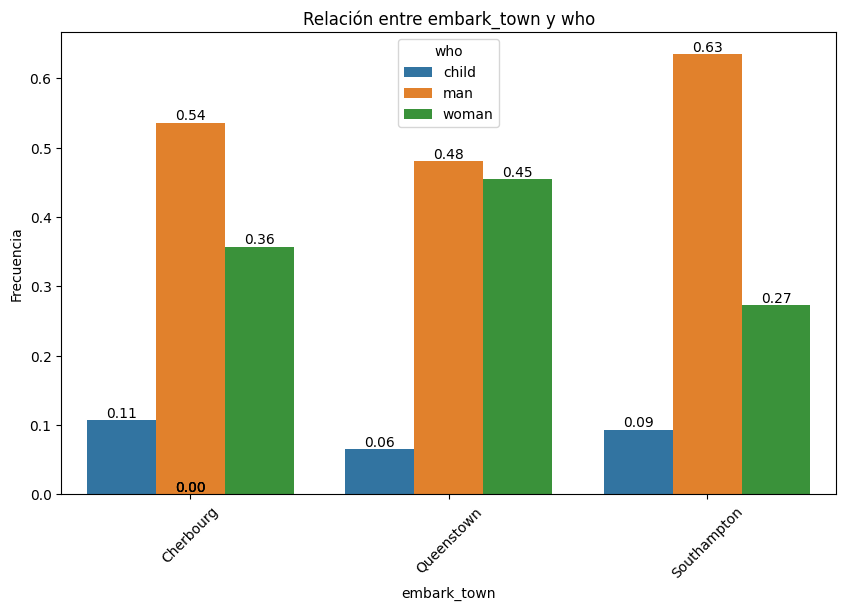

In [32]:
plot_categorical_relationship_fin(df_2, "embark_town","who", relative_freq= True, show_values= True)

Entre estas dos gráficas podemos sacar la conclusión que desde el puerto de Cherbourg embarcaron más de la mitad de pasajeros de primera clase, los cuales tenían mayor tasa de supervivencia. En segundo lugar desde el puerto de Queenstown embarcaron un 45% de mujeres, siendo otro valor determinante en la supervivenvia.


4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

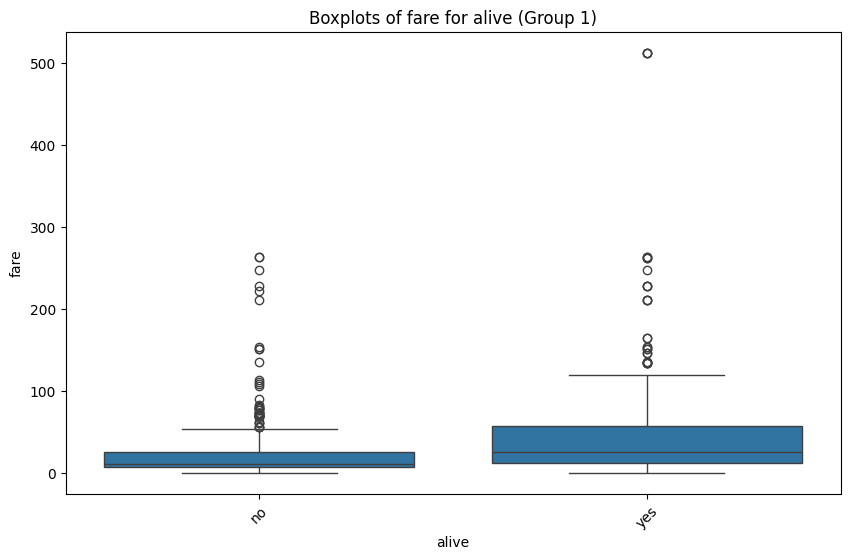

In [34]:
plot_grouped_boxplots(df_2,"alive","fare")

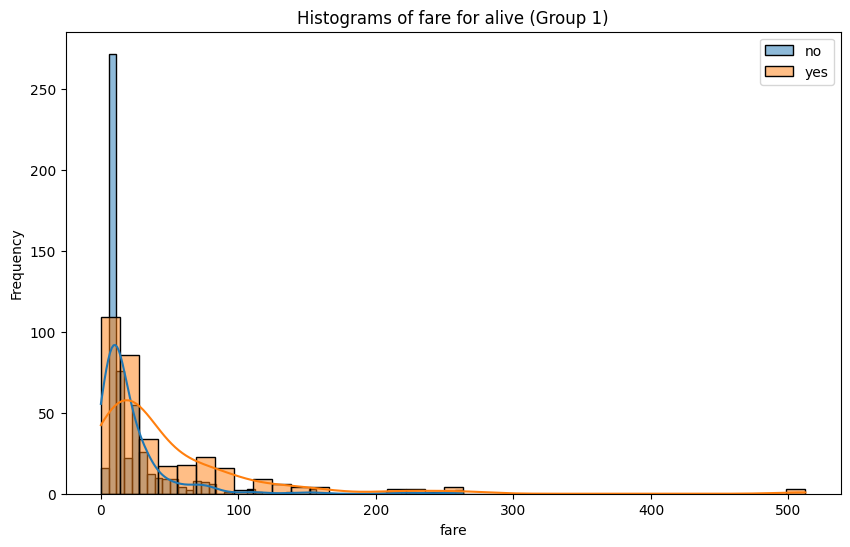

In [35]:
plot_grouped_histograms(df_2, "alive","fare", group_size = 2)

Se aprecia una posible existencia de influencia en la supervivencia con el precio del pasaje

Prueba U de Mann-Whitney

In [36]:
grupo_a = df_2.loc[df_2.alive == "yes"]["fare"]
grupo_b = df_2.loc[df_2.alive == "no"]["fare"]

u_stat, p_value = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_value)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


El valor p está por debajo de 0.05, por lo tanto confirmamos la existencia de una relación estadística entre ambas variables.


5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

In [42]:
df_2.loc[df_2.fare == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.0,0.0,Third,man,True,Southampton,no,True,0
263,male,40.0,0.0,First,man,True,Southampton,no,True,0
271,male,25.0,0.0,Third,man,True,Southampton,yes,True,0
277,male,NaN,0.0,Second,man,True,Southampton,no,True,0
302,male,19.0,0.0,Third,man,True,Southampton,no,True,0
413,male,NaN,0.0,Second,man,True,Southampton,no,True,0
466,male,NaN,0.0,Second,man,True,Southampton,no,True,0
481,male,NaN,0.0,Second,man,True,Southampton,no,True,0
597,male,49.0,0.0,Third,man,True,Southampton,no,True,0
633,male,NaN,0.0,First,man,True,Southampton,no,True,0


Habrán ganado algún concurso o son la tripulación

In [43]:
df_2.loc[df_2.fare == df_2.fare.max()]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0


Fueron tres personas y sobrevivieron todos


6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muéstralo numérica o visualmente.


In [45]:
def trivariant_analysis(df, directora, cat2, num1, group_size = 3, bins = "auto"):
    col_directora = directora
    col_1 = cat2
    col_2 = num1
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_grouped_histograms(df_datos,col_1,col_2, group_size= group_size, bins = bins)

Respuesta Southampton:


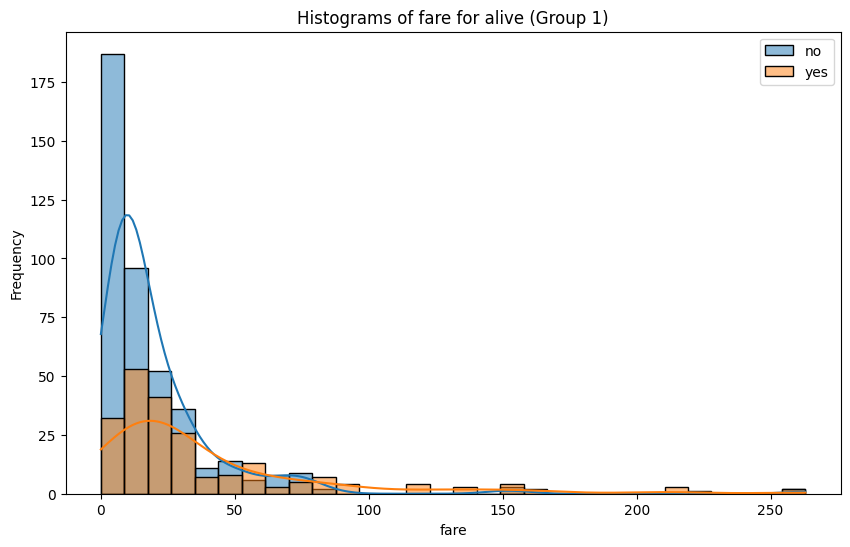

Respuesta Cherbourg:


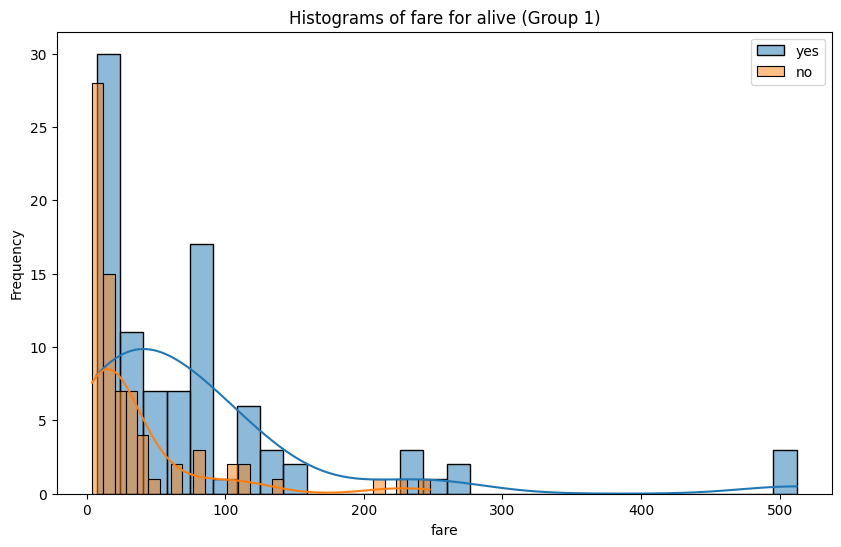

Respuesta Queenstown:


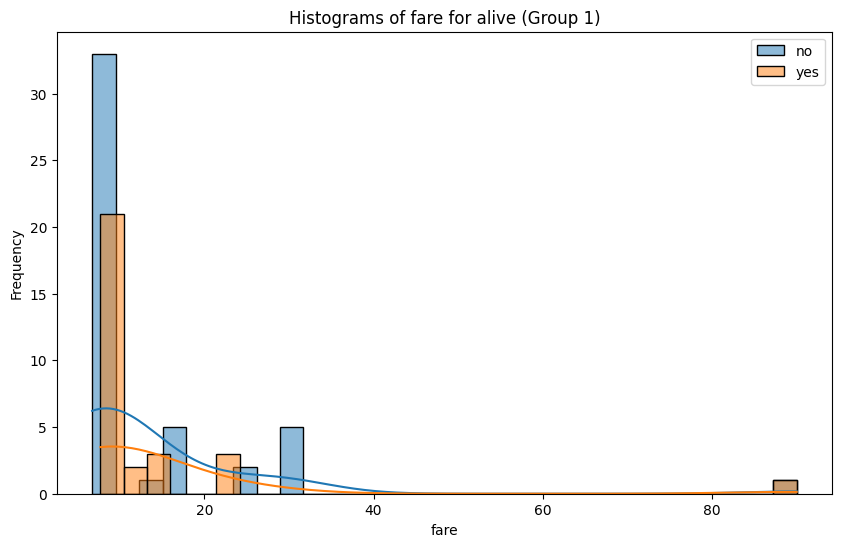

Respuesta nan:


In [46]:
trivariant_analysis(df, "embark_town","alive","fare", 2, 30)


7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?


*Necesitamos hacer una agrupación de edad para poder contestar a la pregunta, para ello pintamos la distribución de la misma y elegimos cómo hacer el binning de esta*

(2,)


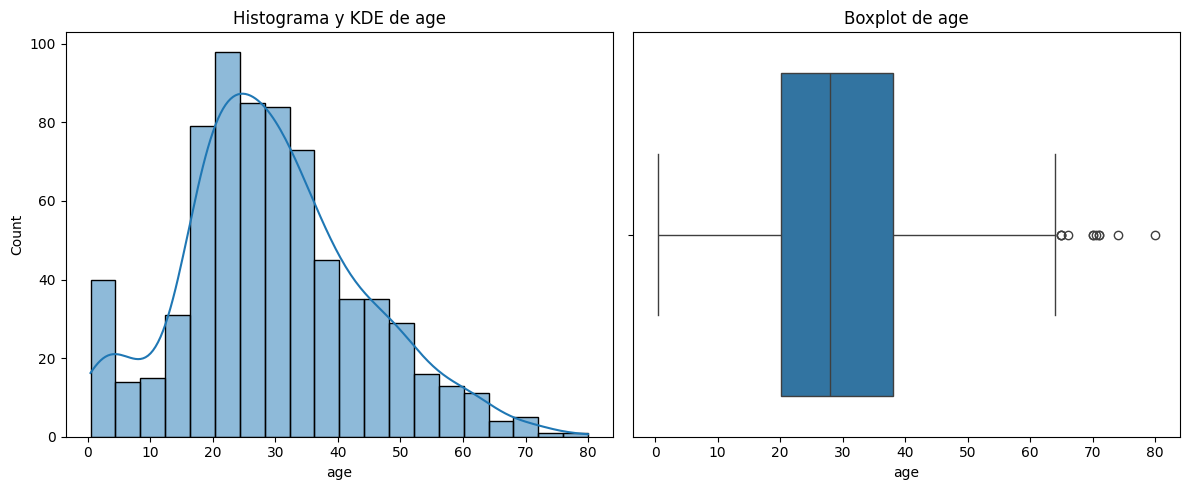

In [51]:
plot_combined_graphs(df_2,["age"])

In [52]:
df_2.age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [54]:
# Escojo cuartiles como límites:
bins = [0,22,30,35,80]
df_2["cat_age"] = pd.cut(df_2.age, bins = bins, labels = ["age_1","age_2","age_3","age_4"])

In [57]:
def tricategorical_analysis(df_datos, directora, otras, relativa = False, muestra_valores = False):
    col_directora = directora
    col_1 = otras[0]
    col_2 = otras[1]
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= relativa, show_values= muestra_valores)

Respuesta age_1:


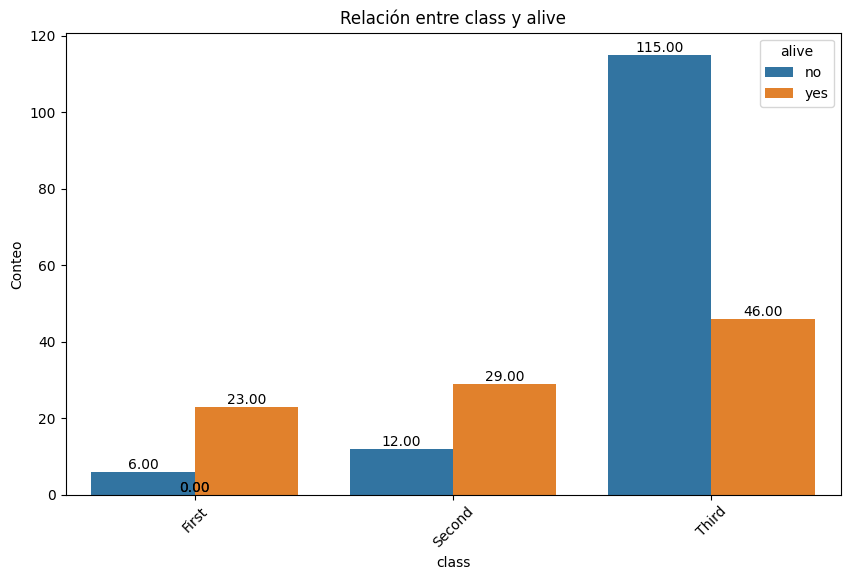

Respuesta age_4:


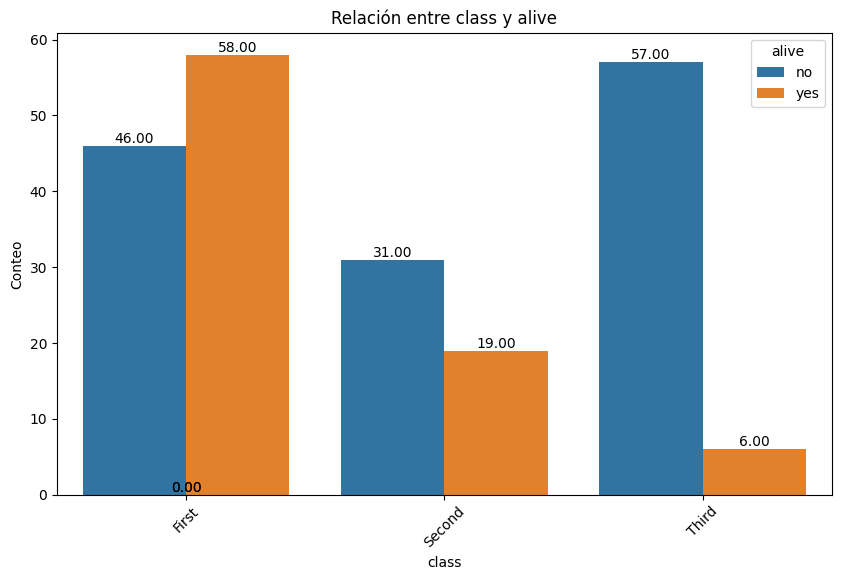

Respuesta age_2:


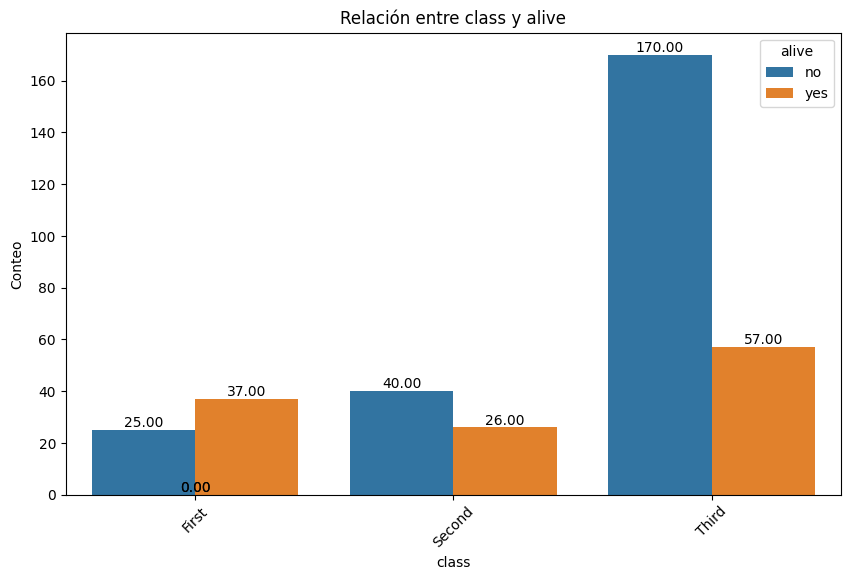

Respuesta age_3:


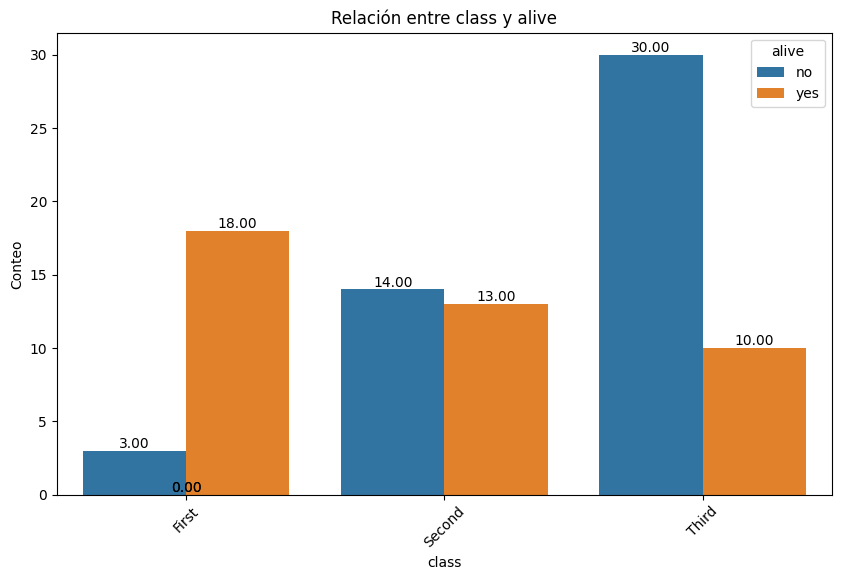

In [58]:
# Ahora hago el multivariante
tricategorical_analysis(df_datos= df_2, directora = "cat_age", otras = ["alive","class"], muestra_valores = True)

*En términos relativos, la combinación cat_age1-Primera clase, es decir menores de 22 en primera clase es la que mayor ratio de supervivencia presenta, siendo los mayores de 35 (cat_age_3 y cat_age_4 conjuntamente) de tercera clase la que peor ratio de supervivencia tiene*

Respuesta age_1:


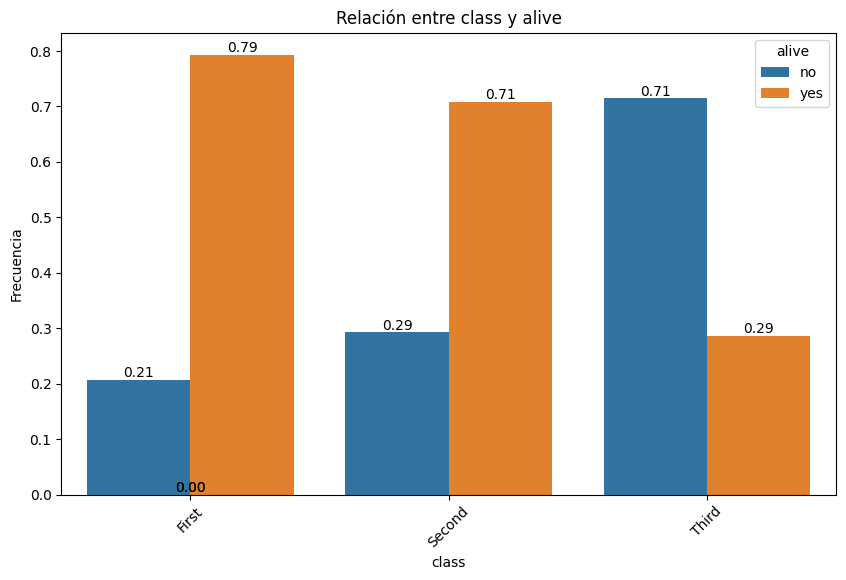

Respuesta age_4:


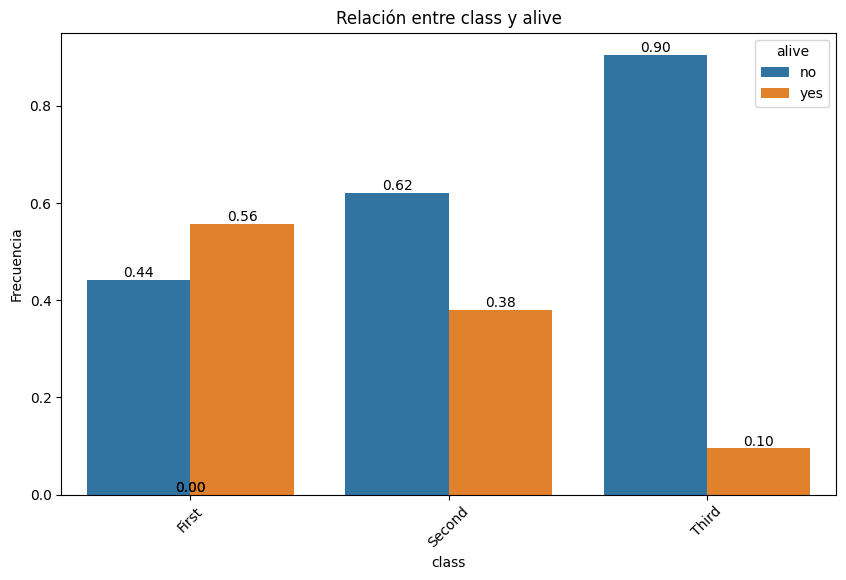

Respuesta age_2:


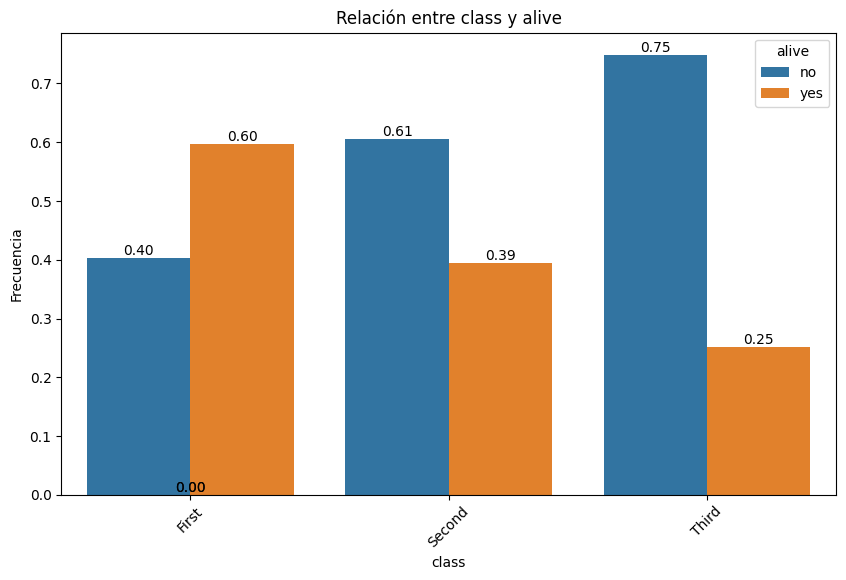

Respuesta age_3:


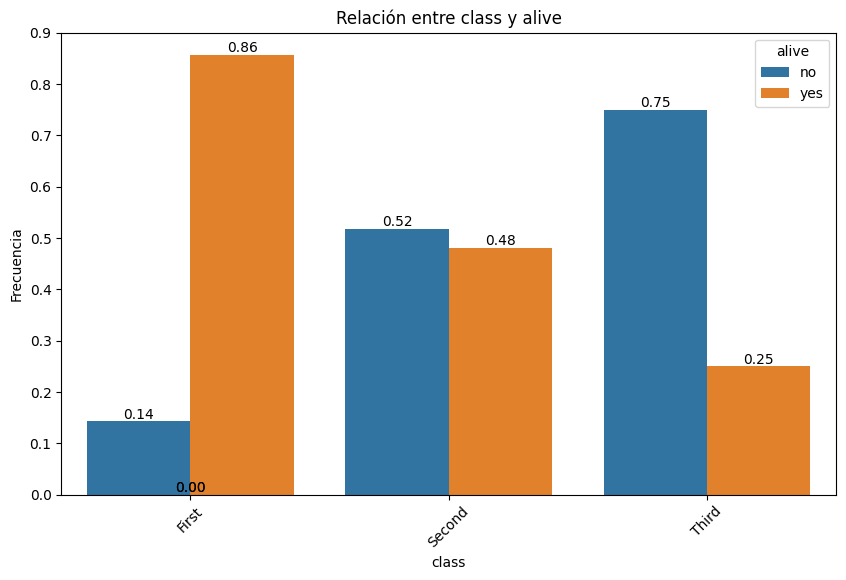

In [60]:
tricategorical_analysis(df_datos= df_2, directora = "cat_age", otras = ["alive","class"], relativa= True, muestra_valores = True)

*En términos absolutos se salvaron más personas que viajaban en primera clase y eran mayores de 35 años, aunque con 56 supervivientes la combinación tercera clase y edades entre 22 y 30 años también estuvieron ahí. Por el otro lado perecieron más los menores de 22 años que viajaban en tercera y las personas entre 30 y 35 años que también viajaban en tercera.*


8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [61]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}

for valor in df_2[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] # Ojo al orden quiero ver para cada oferta como es la distribución de educacion

Respuesta no:


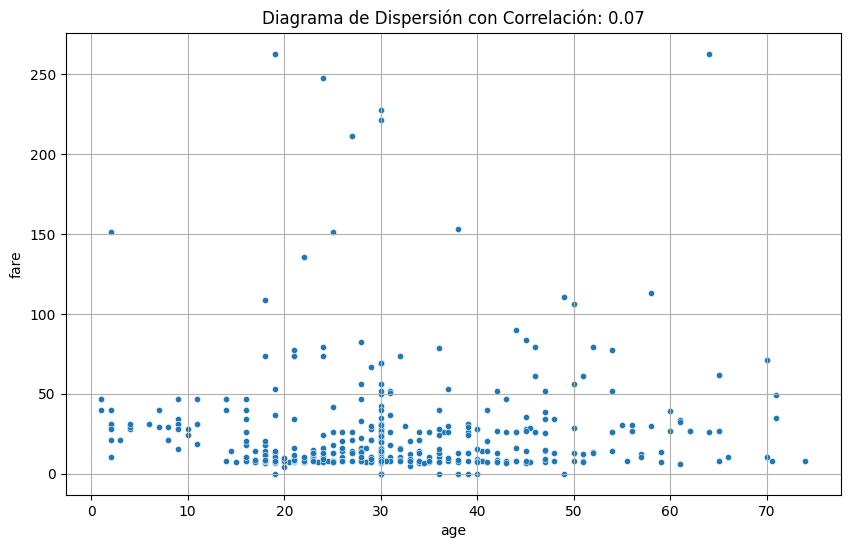

Respuesta yes:


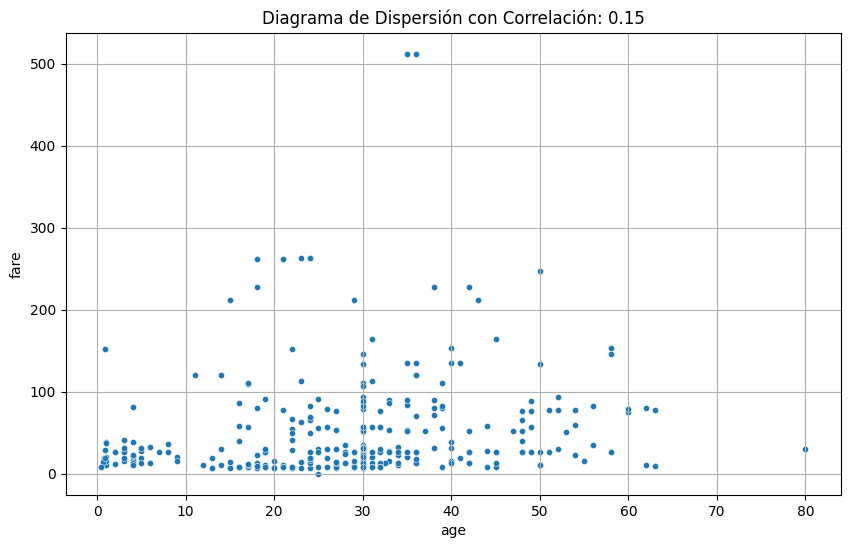

In [62]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

*No se ve una correlación entre edad y el precio del billete independientemente de si se salvaron o no*
*Esto no quiere decir que entre supervivencia y precio y superviviecia y edad no hay cierta relación (de hecho comparando las dos figuras se puede intuir que la edad media es menor entre los supervivientes que entre los fallecidos y el rango de precios de los supervivientes es mayor que el de los fallecidos), que estarían provocadas por la supervivencia superior en mujeres y niños, y en los pasajeros de primera y segunda clase (con precios medios mayores). Un chequeo rápido a las medias (aunque habría que hacer los test correspondientes)*

In [64]:
df_2.groupby("alive")[["age","fare"]].mean()

,age,fare
alive,,
no,30.626179,22.117887
yes,28.343690,48.395408


## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?